# ***Ensemble Learning & Random Forests***

## ***Voting Classifier***

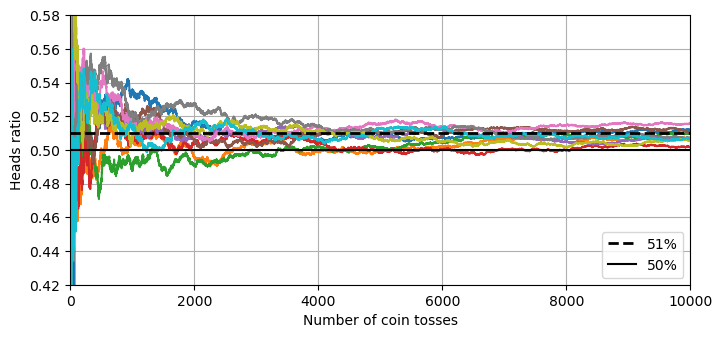

In [1]:
import matplotlib.pyplot as plt
import numpy as np

heads_proba = 0.51
rng = np.random.default_rng(seed=42)
coin_tosses = (rng.random((10000, 10)) < heads_proba).astype(np.int32)
cumulative_heads = coin_tosses.cumsum(axis=0)
cumulative_heads_ratio = cumulative_heads / np.arange(1, 10001).reshape(-1, 1)

plt.figure(figsize=(8, 3.5))
plt.plot(cumulative_heads_ratio)
plt.plot([0, 10000], [0.51, 0.51], "k--", linewidth=2, label="51%")
plt.plot([0, 10000], [0.5, 0.5], "k-", label="50%")
plt.xlabel("Number of coin tosses")
plt.ylabel("Heads ratio")
plt.legend(loc="lower right")
plt.axis([0, 10000, 0.42, 0.58])
plt.grid()

plt.show()

***Let's say I have trained many classifier all give around 80% accuracy `Logistic Regression, SVM, Random forest, KNN classifier`***

- ***A very simple solution is to aggregate the predictions of all the classifiers & the class that get the most vote is ensemble prediction ~ the mejority vote classifier is called hard voting classifier*** 
<!-- ![image.png](image.png) -->

In [2]:
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [3]:
x, y = make_moons(n_samples=500, noise=0.30, random_state=42)
x_train, x_test,y_train, y_test = train_test_split(x, y, random_state=42)

voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('rf',RandomForestClassifier(random_state=42)),
        ('svc', SVC(random_state=42))
    ]
)

voting_clf.fit(x_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svc', SVC(random_state=42))])

- When fit the voting classifier 
- It clones all the estimators & fit the clones 
- 

In [4]:
for name, clf in voting_clf.named_estimators_.items():
    print(name, clf.score(x_test, y_test))

lr 0.864
rf 0.896
svc 0.896


- When call the voting classifier's `predict()` method it performs hard voting

## ***Bagging & Pasting***

- ***Another simple way to get a diverse set of classifiers is to Use the same algorithm for every predictor but train them on different random subset of the training set***
- ***When sampling is performed with replacement then it's called `bagging` & when without replacement it's called `pasting`***

***Now to predict on a new instance we just aggrigate the predictions of all the predictors***
- **For classification aggrigation fuc is statistical mode `most frequent with hard voting`**
- **For regression it's just average**

***Each individual predictor has higher bias than if it was trained on the original data***

`Use bagging when the dataset is noisy & model is prone to overfitting, pasting is computationally efficient`

`Predictions can also be done parallely`

In [6]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(DecisionTreeClassifier(),n_estimators=500, max_samples=100, n_jobs=-1, random_state=42) # n_jobs means no of CPU core to use, -1 for all core 

bag_clf.fit(x_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=100,
                  n_estimators=500, n_jobs=-1, random_state=42)

***So the ensemble has compareable higher bias & smaller variance*** 

### ***Out of Bag Evluation*** 
***In bagging some instance may sampled several times & some are not sampled at all those are czlled `out of bag`***

***A bagging ensemble can be evaluated on the OOB instances without the need for a seperate validation set, set `oob_score=True` for a OOB evaluation after training***

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(DecisionTreeClassifier(),n_estimators=500, max_samples=100,oob_score=True, n_jobs=-1, random_state=42) 

bag_clf.fit(x_train, y_train)
bag_clf.oob_score_ # OOB score evaluated 92.5% accuracy

0.9253333333333333

In [ ]:
from sklearn.metrics import accuracy_score
y_pred = bag_clf.predict(x_test)
accuracy_score(y_test, y_pred) # Actual accuracy 90.4%

0.904

### ***Random patches & Random subspaces***
- **SAmpling of features is also allowed**
- **Sampling both instance & feature is RP & Keeping all instance sampling features is RS**

## ***Random Forest***